In [139]:
import cv2
import numpy as np
from sklearn.cluster import MeanShift, estimate_bandwidth
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops

In [140]:
def load_image(source):
    image_bgr = cv2.imread(source)

    if image_bgr is None:
        raise FileNotFoundError(f"Error: Imagen no encontrada en {source}")

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    return image_rgb

In [141]:
def to_grayscale(image):
    return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [142]:
def apply_clahe_rgb(image, clip_limit=3.0, grid_size=(8,8)):
    """
    Aplica CLAHE a cada canal de una imagen RGB.
    """

    clahe = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=grid_size
    )

    r, g, b = cv2.split(image)

    r = clahe.apply(r)
    g = clahe.apply(g)
    b = clahe.apply(b)

    return cv2.merge((r, g, b))

In [143]:
def apply_blur(image, kernel_size=(5,5)):
    return cv2.GaussianBlur(image, kernel_size, 0)

In [144]:
def increase_contrast(image, alpha=1.8, beta=0):
    """
    alpha = contraste (1.0–3.0)
    beta = brillo (-100 a 100)
    """
    return cv2.convertScaleAbs(image, alpha=alpha, beta=beta)

In [145]:
def prepare_pixel_data(image_rgb):
    if len(image_rgb.shape) == 2:  # imagen en grises
        pixel_data = image_rgb.reshape(-1, 1)
    else:  # imagen RGB
        pixel_data = image_rgb.reshape(-1, 3)
    return pixel_data

In [146]:
def apply_meanshift(pixel_data):
    print("Iniciando MeanShift...")

    bandwidth = estimate_bandwidth(
        pixel_data,
        quantile=0.2,
        n_samples=500,
        random_state=42
    )

    ms = MeanShift(bandwidth=bandwidth, bin_seeding=True, n_jobs=-1)
    ms.fit(pixel_data)

    labels = ms.labels_
    centers = ms.cluster_centers_
    n_clusters = len(np.unique(labels))

    print(f"Número de clústeres estimados: {n_clusters}")

    return labels, centers, n_clusters


In [147]:
def create_segmented_image(image_rgb, labels, n_clusters):
    segmented = labels.reshape(image_rgb.shape[:2])

    colors = np.random.randint(0, 255, size=(n_clusters, 3))

    colored = np.zeros_like(image_rgb)

    for i in range(n_clusters):
        colored[segmented == i] = colors[i]

    return segmented, np.uint8(colored)

In [148]:
def label_segments(image_rgb, segmented_image, colored_image, labels):
    output = colored_image.copy()

    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 1.0
    font_color = (255, 255, 255)
    font_thickness = 2

    for i, cluster_id in enumerate(np.unique(labels)):

        mask = (segmented_image == cluster_id).astype(np.uint8) * 255

        num_labels, component_labels, stats, centroids = cv2.connectedComponentsWithStats(
            mask, 8, cv2.CV_32S
        )

        for j in range(1, num_labels):

            area = stats[j, cv2.CC_STAT_AREA]
            centroid_x, centroid_y = centroids[j]

            if area > (image_rgb.shape[0] * image_rgb.shape[1] * 0.005):

                label_char = chr(ord('A') + i)

                text_size = cv2.getTextSize(
                    label_char, font, font_scale, font_thickness
                )[0]

                text_x = int(centroid_x - text_size[0] / 2)
                text_y = int(centroid_y + text_size[1] / 2)

                cv2.rectangle(
                    output,
                    (text_x - 5, text_y - text_size[1] - 5),
                    (text_x + text_size[0] + 5, text_y + 5),
                    (0, 0, 0),
                    -1
                )

                cv2.putText(
                    output,
                    label_char,
                    (text_x, text_y),
                    font,
                    font_scale,
                    font_color,
                    font_thickness,
                    cv2.LINE_AA
                )

    return output

In [149]:
def show_results(original, segmented, n_clusters):
    plt.figure(figsize=(18, 8))

    plt.subplot(1, 2, 1)
    plt.imshow(original)
    plt.title("Imagen Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(segmented)
    plt.title(f"Imagen Segmentada con MeanShift ({n_clusters} clústeres)")
    plt.axis("off")

    plt.show()

Iniciando MeanShift...
Número de clústeres estimados: 2


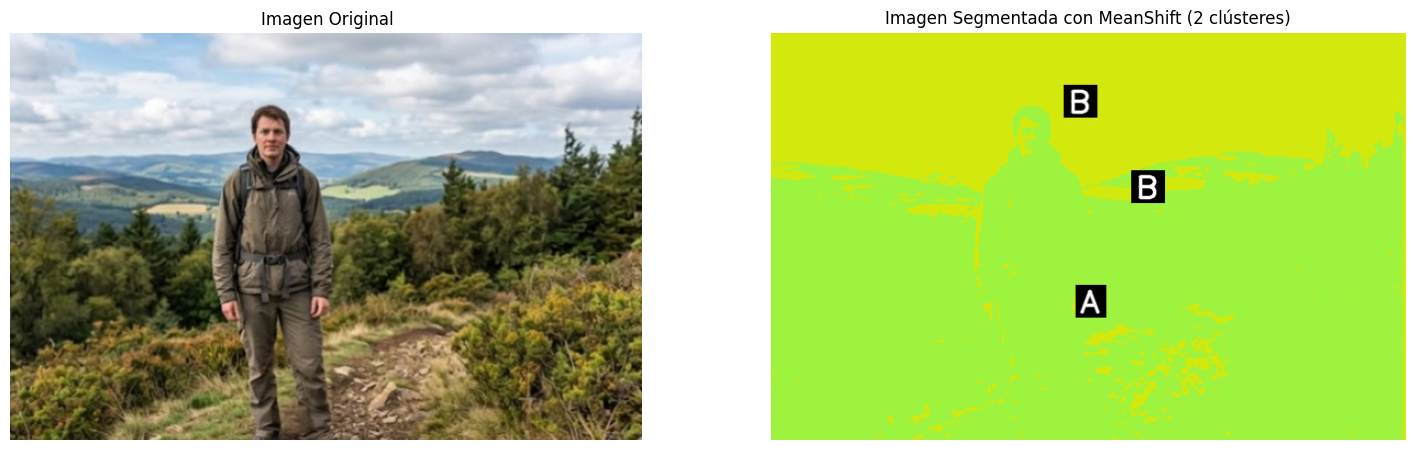

In [150]:
source = "data/imagen1.png" 

image_rgb = load_image(source)
pixel_data = prepare_pixel_data(image_rgb)
labels, centers, n_clusters = apply_meanshift(pixel_data)
segmented_image, colored = create_segmented_image(
    image_rgb, labels, n_clusters
)
labeled_image = label_segments(
    image_rgb,
    segmented_image,
    colored,
    labels
)
show_results(image_rgb, labeled_image, n_clusters)

In [151]:
def show_images(original, gray, contrast, blur, clahe):

    plt.figure(figsize=(20,5))

    plt.subplot(1,5,1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,5,2)
    plt.imshow(gray, cmap="gray")
    plt.title("Escala de grises")
    plt.axis("off")

    plt.subplot(1,5,3)
    plt.imshow(cv2.cvtColor(contrast, cv2.COLOR_BGR2RGB))
    plt.title("Mayor contraste")
    plt.axis("off")

    plt.subplot(1,5,4)
    plt.imshow(cv2.cvtColor(blur, cv2.COLOR_BGR2RGB))
    plt.title("Blur")
    plt.axis("off")

    plt.subplot(1,5,5)
    plt.imshow(cv2.cvtColor(clahe, cv2.COLOR_BGR2RGB))
    plt.title("CLAHE")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

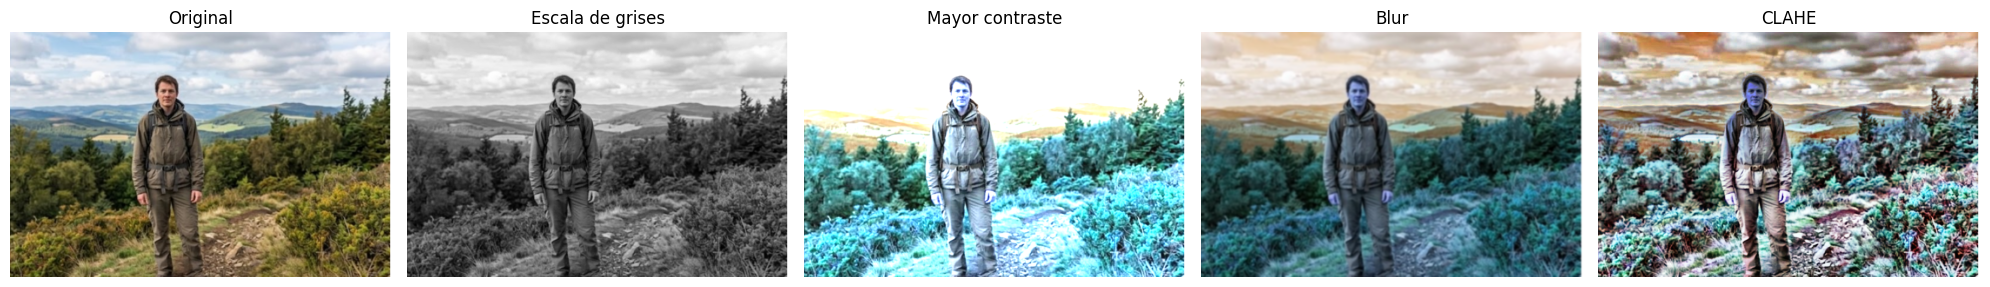

In [152]:
def compara_imagenes(source):
    image_rgb= load_image(source)
    gray = to_grayscale(image_rgb)
    contrast = increase_contrast(image_rgb, alpha=2.0, beta=10)
    image_blur = apply_blur(image_rgb)
    image_clahe = apply_clahe_rgb(image_rgb)
    show_images(image_rgb, gray, contrast, image_blur, image_clahe)
compara_imagenes("data/imagen1.png")

# Mayor contraste

Iniciando MeanShift...
Número de clústeres estimados: 3


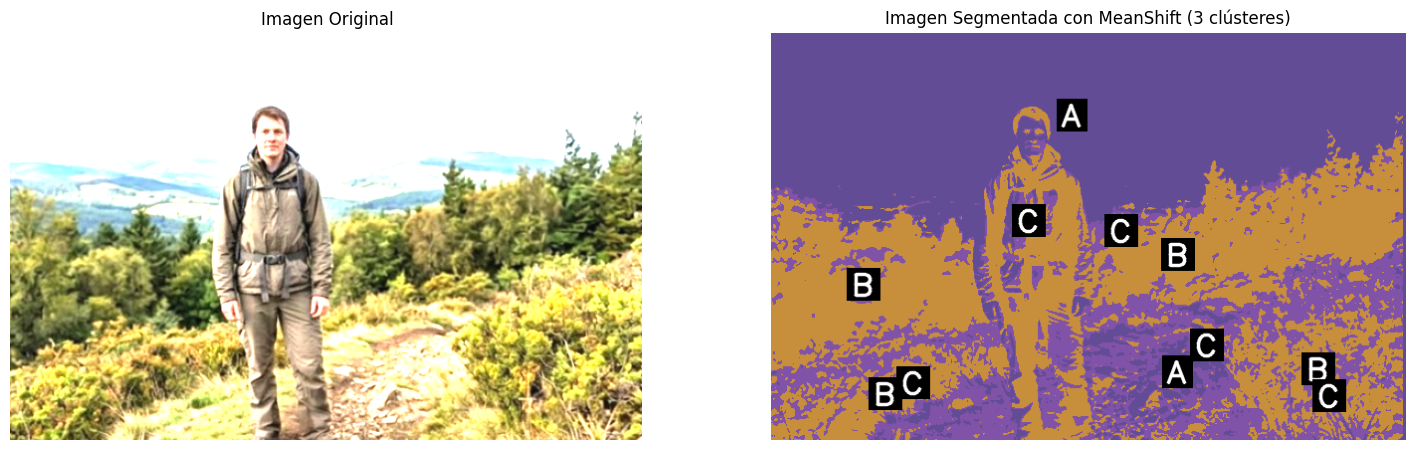

In [153]:
source = "data/imagen1.png" 

image_rgb = load_image(source)
img_contrast = increase_contrast(image_rgb, alpha=2.0, beta=10)
pixel_data = prepare_pixel_data(img_contrast)
labels, centers, n_clusters = apply_meanshift(pixel_data)
segmented_image, colored = create_segmented_image(
    img_contrast, labels, n_clusters
)
labeled_image = label_segments(
    img_contrast,
    segmented_image,
    colored,
    labels
)
show_results(img_contrast, labeled_image, n_clusters)

# Blur

Iniciando MeanShift...
Número de clústeres estimados: 2


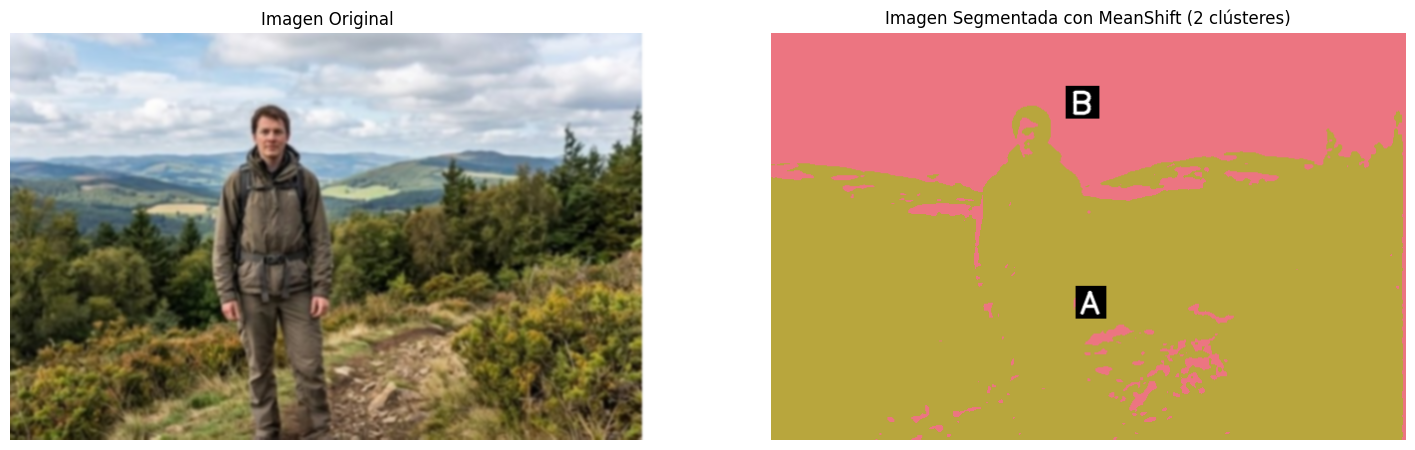

In [155]:
source = "data/imagen1.png" 

image_rgb = load_image(source)
img_blur = apply_blur(image_rgb)
pixel_data = prepare_pixel_data(img_blur)
labels, centers, n_clusters = apply_meanshift(pixel_data)
segmented_image, colored = create_segmented_image(
    img_blur, labels, n_clusters
)
labeled_image = label_segments(
    img_blur,
    segmented_image,
    colored,
    labels
)
show_results(img_blur, labeled_image, n_clusters)

# Clahe

Iniciando MeanShift...
Número de clústeres estimados: 1


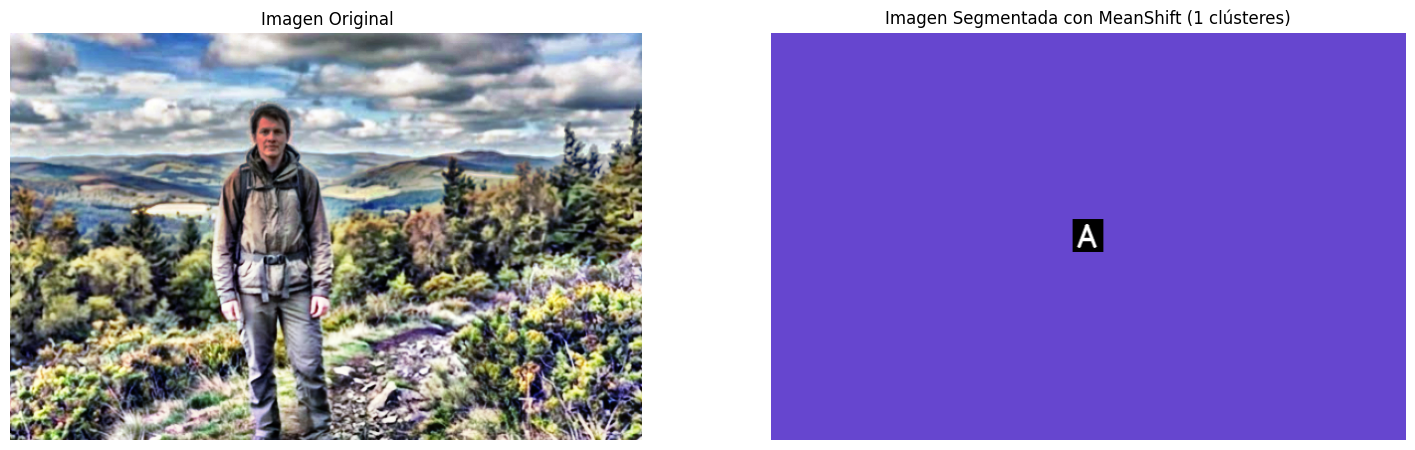

In [158]:
source = "data/imagen1.png" 

image_rgb = load_image(source)
img_clahe = apply_clahe_rgb(image_rgb)
pixel_data = prepare_pixel_data(img_clahe)
labels, centers, n_clusters = apply_meanshift(pixel_data)
segmented_image, colored = create_segmented_image(
    img_clahe, labels, n_clusters
)
labeled_image = label_segments(
    img_clahe,
    segmented_image,
    colored,
    labels
)
show_results(img_clahe, labeled_image, n_clusters)